In [3]:
import trimesh

# Pfad zu deiner OFF-Datei
mesh = trimesh.load('../data/ModelNet40/chair/train/chair_0001.off')

print(mesh)
mesh.show()


<trimesh.Trimesh(vertices.shape=(844, 3), faces.shape=(2234, 3))>


In [4]:
print(mesh.vertices.shape)  
print(mesh.faces.shape) 

(844, 3)
(2234, 3)


In [5]:
points, face_idx = trimesh.sample.sample_surface(mesh, 2000)

print(points.shape)

(2000, 3)


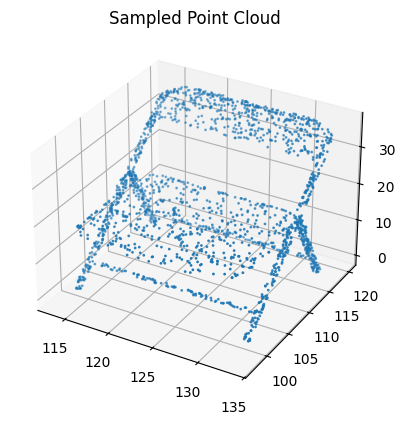

In [6]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=1)
plt.title("Sampled Point Cloud")
plt.show()


In [7]:
import torch
points = torch.tensor(points, dtype=torch.float32)
points.shape

torch.Size([2000, 3])

In [11]:
import sys
sys.path.append("..")
from dataset import ModelNet40Dataset
from torch.utils.data import DataLoader

In [39]:

dataset = ModelNet40Dataset(
    root_dir="../data/ModelNet40",
    split="train",
    num_points=10000
)
dataloader = DataLoader(dataset, batch_size=1, shuffle=True)



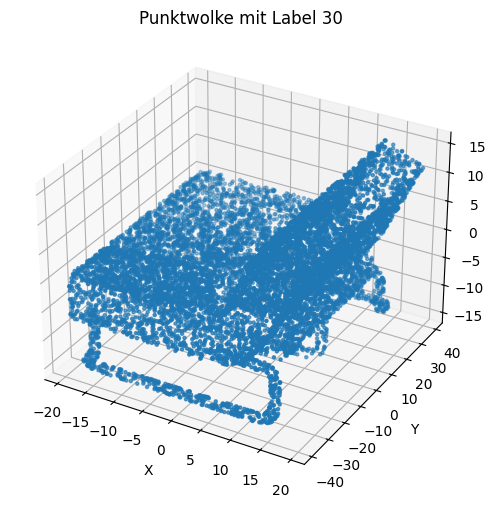

In [40]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # wichtig für 3D-Plots

# Batch holen (nur erster Durchlauf)
for points, labels in dataloader:
    pc = points[0].numpy()  # [1024, 3], eine Punktwolke
    label = labels[0].item()
    break

# 3D-Plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pc[:, 0], pc[:, 1], pc[:, 2], s=5)
ax.set_title(f"Punktwolke mit Label {label}")
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()